In [33]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [34]:
load_dotenv()

True

In [35]:
class ParentState(TypedDict):
    topic : str
    eng_response : str
    hin_response : str

# Creating Subgraph

In [36]:
subgraph_llm = ChatOpenAI()

In [37]:
def translate_to_hindi(state : ParentState):
    ''' 
    Translate the given text to hindi language. Do not add any additional contents
    '''
    prompt = f"""
                Translate the following text to Hindi.
                Keep it natural and clear. Do not add extra content.

                Text:
                {state["eng_response"]}
            """.strip()
    response = subgraph_llm.invoke(prompt).content

    return {'hin_response' : response}

In [38]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate',translate_to_hindi)

subgraph_builder.add_edge(START,'translate')
subgraph_builder.add_edge('translate',END)

subgraph = subgraph_builder.compile()

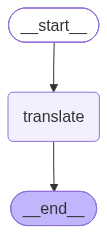

In [39]:
subgraph

In [40]:
response = subgraph.invoke({'eng_response' : "I am okay "})

In [41]:
response

{'eng_response': 'I am okay ', 'hin_response': 'मैं ठीक हूं।'}

# Creating Parent Graph

In [42]:
parent_llm = ChatOpenAI()

In [43]:
def generate(state : ParentState):
    '''
    generate a short essay based on the user given topic.
    '''
    response = parent_llm.invoke(state['topic']).content

    return {'eng_response' : response}

In [44]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("generate", generate)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'generate')
parent_builder.add_edge('generate', 'translate')
parent_builder.add_edge('translate', END)

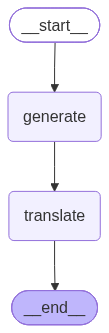

In [45]:
graph = parent_builder.compile()

graph

In [46]:
graph.invoke({'topic': 'What is Gradient Descent, Explain in 50 words.'})

{'topic': 'What is Gradient Descent, Explain in 50 words.',
 'eng_response': 'Gradient Descent is an optimization algorithm used to minimize a function by iteratively moving towards the direction of steepest descent of the gradient. It calculates the gradient of the function at a given point and updates the parameters in the direction of the negative gradient to reach the global minimum.',
 'hin_response': 'ग्रेडियेंट गिरावट एक अनुकुलन एल्गोरिदम है जिसे किसी समीकरण को कम करने के लिए प्रयोग किया जाता है जिसे ग्रेडियेंट की सबसे तीव्र गिरावट की दिशा में चलते हुए आवर्ती रूप से कम किया जाता है। यह दिए गए बिंदु पर समीकरण की ग्रेडियेंट की गणना करता है और पैरामीटर को नेगेटिव ग्रेडियेंट की दिशा में अपडेट करता है ताकि वह ग्लोबल न्यूनतम तक पहुंच सके।'}